# Explore candidate cell fates

Pseudotime orders cell states along a process. **Fate mapping** adds a different
question: how strongly does each cell connect to several possible endpoints?

CyteArc models walks through the cell graph, favoring movement toward higher pseudotime.
The chosen terminal populations act as absorbing endpoints: once a walk reaches one,
it stops. The probability of reaching each endpoint summarizes the cell's position
relative to those choices. It does not track a living cell or prove its future identity.

We continue the developing-pancreas example from [](pseudotime.ipynb), using Alpha, Beta,
and Delta as candidate outcomes. Their familiar markers include Gcg, Ins1/Ins2, and
Sst, respectively. Published annotations guide this example; another dataset needs its
own endpoint evidence.

## Open the prepared analysis

In [1]:
# Import array operations and CyteArc for defining trajectory endpoints.
import numpy as np
import pandas as pd

import cytearc
from cytearc.plotting import CellField, ColorScale

# Keep routine progress messages out of the teaching output.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="cytearc_datasets",
    zarr=True,
)

Started: 2026-10-08T11:03:12.438718Z | Wall time: 15.390 s

Open the downloaded store and its saved analysis.

In [2]:
# Open the datastore for the following analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr", nthreads=4)

# Reuse the saved run and its frozen cell selection.
analysis_run = ds.pipeline.open(label="docs_default")

# Keep the graph used by the saved analysis.
graph = analysis_run["connectivity_map"]

# Inspect the opened assays and their dimensions.
ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'clusters', 'clusters_coarse'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'highly_variable_genes', 
            'nCells'

Started: 2026-10-08T11:03:27.833791Z | Wall time: 2.458 s

## Orient the graph

Repeat the source and sink weighting from [](pseudotime.ipynb). Ductal cells share a total
of -1, and all Alpha, Beta, and Delta cells together share +1. These totals balance the
source against the pooled sinks; they do not give each terminal cell type equal weight.

In [3]:
# Read the published cell-type labels for the selected cells.
annotations = ds.cells.fetch("clusters", key="I")

# Mark ductal cells as the source population.
source = annotations == "Ductal"

# Mark the pooled terminal populations.
sink = np.isin(annotations, ["Alpha", "Beta", "Delta"])

# Require at least one annotated source cell and one sink cell.
if not source.any() or not sink.any():
    raise ValueError("Source and sink annotations must both be present")

# Start every graph cell with zero source or sink mass.
source_sink_vector = np.zeros(len(annotations), dtype=float)

# Share total mass -1 among the source cells.
source_sink_vector[source] = -1.0 / source.sum()

# Share total mass +1 among the pooled sink cells.
source_sink_vector[sink] = 1.0 / sink.sum()

# Orient the graph using the chosen source and sinks.
pseudotime_ref = ds.trajectory.pseudotime(graph, ss_vec=source_sink_vector)

# Check the number of cells used to orient the graph.
pd.Series({"source cells": int(source.sum()), "sink cells": int(sink.sum())})

source cells     916
sink cells      1142
dtype: int64

Started: 2026-10-08T11:03:30.293252Z | Wall time: 0.633 s

## Select the terminal populations

The live `clusters` column above contains published cell-type names. The saved run's
`clusters` result contains computed integer labels. For this example we choose one
computed cluster per candidate fate, using its most common published annotation.

First inspect the annotation shares within each computed cluster. These two label
arrays cover the same selected cells in the prepared store.

In [4]:
# Keep the computed clustering used to define terminal boundaries.
sink_labels_ref = analysis_run["clusters"]

# Read its labels in the run's cell order.
sink_labels = analysis_run.cells.fetch("clusters")

# Check that imported and computed labels cover the same cell count.
assert len(annotations) == len(sink_labels)

# Measure each published annotation's share within each cluster.
shares = pd.crosstab(
    sink_labels,
    annotations,
    rownames=["cluster"],
    colnames=["annotation"],
    normalize="index",
)

# Show the majority annotation and its share for every cluster.
sink_table = pd.DataFrame(
    {"annotation": shares.idxmax(axis=1), "majority share": shares.max(axis=1)}
)

# Inspect every candidate cluster before choosing terminal boundaries.
sink_table

,annotation,majority share
cluster,,
1,Pre-endocrine,0.843915
2,Ductal,0.769231
3,Alpha,0.862069
4,Ductal,0.967442
5,Ductal,0.672646
6,Pre-endocrine,0.605882
7,Epsilon,0.658537
8,Ductal,0.827586
9,Delta,0.741935


Started: 2026-10-08T11:03:30.928108Z | Wall time: 0.111 s

Keep the clusters whose majority annotations match our three candidate fates. Requiring
one cluster per fate makes a missing or ambiguous choice visible instead of selecting
an endpoint arbitrarily.

In [5]:
# Choose the three candidate terminal identities.
candidate_fates = ["Alpha", "Beta", "Delta"]

# Keep one cluster for each requested terminal identity.
selected = sink_table.loc[sink_table["annotation"].isin(candidate_fates)]

# Count the candidate fates before checking for missing or duplicated matches.
n_fates = len(candidate_fates)

# Check that each requested fate identifies exactly one cluster.
valid_fates = len(selected) == n_fates == selected["annotation"].nunique()

# Reject a missing or ambiguous terminal-cluster choice.
if not valid_fates:
    raise ValueError("Each candidate fate must match exactly one cluster")

# Keep the computed cluster label as a column.
selected = selected.reset_index(names="sink label")

# Index the table by the candidate annotation.
selected = selected.set_index("annotation")

# Match the order used for the probability columns and plots.
selected = selected.loc[candidate_fates]

# Extract the computed cluster labels for the terminal boundaries.
terminal_labels = selected["sink label"].astype(int).tolist()

# Attach readable fate names to those cluster labels.
sink_names = dict(zip(terminal_labels, candidate_fates, strict=True))

# Inspect the selected terminal clusters and their annotation purity.
selected

,sink label,majority share
annotation,,
Alpha,3,0.862069
Beta,10,0.984000
Delta,9,0.741935


Started: 2026-10-08T11:03:31.040990Z | Wall time: 0.010 s

The selected Delta cluster has a majority share of about 0.74, so it includes cells
with other annotations. Every cell in a selected cluster becomes a boundary for this
model. This is an exploratory endpoint choice, not a pure set of terminal cells.
Before using it for a biological claim, inspect marker evidence and compare alternative
boundaries. See [](annotation.ipynb) for marker checks.

## Calculate the probabilities

In [6]:
# Calculate absorption probabilities for the chosen endpoints.
fate_ref = ds.trajectory.fate(
    pseudotime_ref, sink_labels_ref, sinks=terminal_labels
)

# Load the probabilities and their validity mask.
fate = ds.trajectory.load_fate(fate_ref)

# Compare valid probability rows with the complete graph-cell count.
{"valid probability rows": int(fate.valid.sum()), "graph cells": len(fate.valid)}

{'valid probability rows': 3696, 'graph cells': 3696}

Started: 2026-10-08T11:03:31.053307Z | Wall time: 2.240 s

The output reports how many graph cells have valid probabilities. Summarize only those
rows. Each probability column is one candidate fate, and the columns should sum to one
for each valid cell.

In [7]:
# Match fate names to the saved probability-column order.
fate_names = [sink_names[int(label)] for label in fate.sink_labels]

# Keep valid rows and label each probability column by fate.
probabilities = pd.DataFrame(fate.values[fate.valid], columns=fate_names)

# Measure each probability row's deviation from a total of one.
probabilities["row-sum error"] = abs(probabilities.sum(axis=1) - 1.0)

# Inspect probability ranges and the error in their row sums.
probabilities.agg(["min", "median", "max"])

,Alpha,Beta,Delta,row-sum error
min,0.000000,0.000000,0.000000,0.000000e+00
median,0.345601,0.317223,0.308123,0.000000e+00
max,1.000000,1.000000,1.000000,1.192093e-07


Started: 2026-10-08T11:03:33.295022Z | Wall time: 0.012 s

A small row-sum error checks numerical consistency. Likewise, high probability at a
chosen sink is imposed by the model. Neither check supplies independent evidence that
the endpoint choice is biologically correct.

## View the candidate outcomes

Store each probability as a cell column, then plot all three on the same zero-to-one
color scale. This uses the same UMAP as the preceding trajectory analysis.

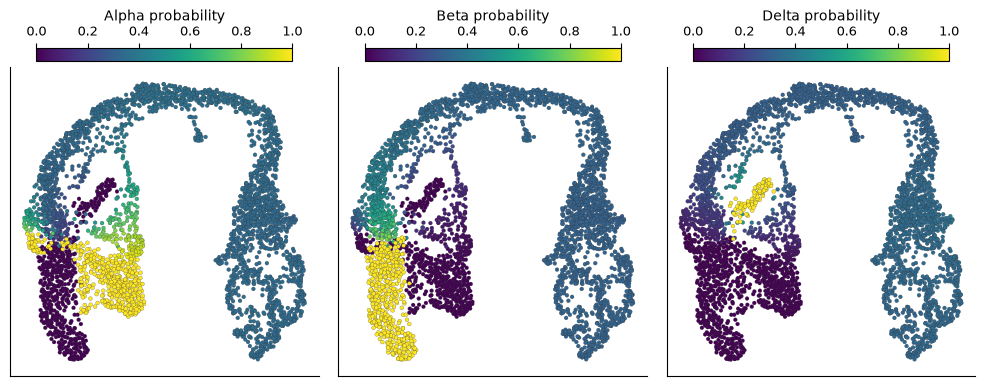

Started: 2026-10-08T11:03:33.308087Z | Wall time: 1.363 s

In [8]:
# Save each fate probability in the matching cell order.
for index, label in enumerate(fate.sink_labels):

    # Save the values in cell metadata using the stated selection.
    ds.cells.insert(
        f"fate_prob_{sink_names[int(label)]}",
        fate.values[:, index],
        key="I",
        overwrite=True,
    )

# Compare the three fate probabilities on a shared zero-to-one scale.
ds.plots.embedding(
    layout=analysis_run["umap"],
    color_by=[
        CellField(
            f"fate_prob_{name}", kind="continuous", label=f"{name} probability"
        )
        for name in candidate_fates
    ],
    n_columns=3,
    color_scale=ColorScale(scope="shared", vmin=0, vmax=1),
    sort_values=True,
)

Look for where the model favors one outcome and where it divides probability between
outcomes. A mixed probability describes this graph and its endpoints; it does not show
that a cell has been observed to choose between those fates.

## Check the assumptions

- The candidate list is incomplete: the dataset also contains Epsilon cells. Valid
  cells must distribute their probability among the three selected outcomes, so this
  example cannot describe every endocrine fate.
- Smooth gradients can arise from graph averaging even when a biological transition
  is abrupt. They do not establish gradual commitment.
- Invalid cells have no interpretable probabilities. Check their number and graph
  components before drawing conclusions.
- Endpoint selection and graph construction can change the result. Compare plausible
  alternatives using [](trajectory_validation.md) before making a lineage claim.

Use [](expression_dynamics.ipynb) to inspect gene profiles along the same pseudotime axis.